# Regimes and convergence — the per-regime metrics table

> **PROVISIONAL.** The regime *taxonomy* is ratified (2026-07-29, `docs/regime_taxonomy.md`):
> membership is assigned from a documented issuance rule, before any price is read. The
> **panel** is not ratified — the constrained class is four issuers under one regulator, and
> five of the six controls are Brazilian. Every number below inherits that.

**What this notebook is.** The S4 deliverable: out-of-fold RMSE, R² and sign hit rate for the
premium, per regime class and per horizon. It is the artifact that every trade sheet, hedge
ratio and convergence number in the project has been waiting on.

**What it is not.** There is no M2 regime classifier, and there does not need to be. The
regime label is read off a filing, so it is an **input** here. A model trained to predict a
label already fixed by a deposit agreement is fitted to its own answer key.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import pandas as pd
from pipeline.viz import theme, figures
from pipeline.convergence.jorda import (PANEL_CAVEATS, TAXONOMY_RATIFIED, TABLE_HORIZONS,
                                        run_panel, s4_metrics_table)
theme.apply()
print(f"taxonomy RATIFIED {TAXONOMY_RATIFIED}   horizons {TABLE_HORIZONS}")
for c in PANEL_CAVEATS: print("  PROVISIONAL:", c)

taxonomy RATIFIED 2026-07-29   horizons (1, 5, 20, 60)
  PROVISIONAL: constrained class is four issuers under ONE regulator -- reduces issuer noise, gives no independent variation in the rule
  PROVISIONAL: fungible class is five Brazilian pairs plus Alibaba -- one country dominates the control


## The table

Out-of-fold. Expanding walk-forward, 5 splits, **embargo = h** — training labels overlap the
test block by h periods, and without the embargo the fit sees its own test window through the
label. Centring fitted train-only. SKHY excluded from every fit.

The predictor is the Jordà local projection M3 already uses: π_{t+h} ~ π_t. **Sign hit rate
scores the change from today's level, not the level** — a premium that is almost always
positive would score ~100% on the level and tell you nothing.

In [2]:
tbl = s4_metrics_table()
tbl.drop(columns=["PROVISIONAL"])

,target,regime,horizon,n,rmse,r2,hit_rate,scope
0,level,fungible,1,23207,0.021217,0.634686,0.570992,"N_train=full, expanding walk-forward, embargo=h"
1,level,fungible,5,23189,0.036991,-0.109723,0.573203,"N_train=full, expanding walk-forward, embargo=h"
2,level,fungible,20,23114,0.037819,-0.156659,0.590551,"N_train=full, expanding walk-forward, embargo=h"
3,level,fungible,60,22913,0.037499,-0.128567,0.596255,"N_train=full, expanding walk-forward, embargo=h"
4,level,one_way_constrained,1,15490,0.030283,0.915916,0.537641,"N_train=full, expanding walk-forward, embargo=h"
5,level,one_way_constrained,5,15476,0.035510,0.884340,0.534311,"N_train=full, expanding walk-forward, embargo=h"
6,level,one_way_constrained,20,15426,0.043881,0.823190,0.539284,"N_train=full, expanding walk-forward, embargo=h"
7,level,one_way_constrained,60,15292,0.059860,0.671047,0.544533,"N_train=full, expanding walk-forward, embargo=h"
8,level,POOLED (all classes),1,38697,0.025240,0.887701,0.557650,"N_train=full, expanding walk-forward, embargo=h"
9,level,POOLED (all classes),5,38665,0.036406,0.766252,0.557636,"N_train=full, expanding walk-forward, embargo=h"


**The classes separate out of sample, in the direction the mechanism predicts.** The
barrier-constrained premium is forecastable — R² 0.92 at h=1, still 0.68 at h=60. The fungible
control's R² is **negative beyond one day**: worse than predicting its own mean. There is no
persistence left in it, which is exactly what a working two-way arbitrage should leave behind.

**The hit rates run the other way, and that is worth saying out loud.** The control's sign hit
rate (57–60%) beats the constrained class's (53%). Level and direction are different
questions: the constrained premium's *level* is highly predictable while its next *move* is
close to a coin flip — the profile of a slow-moving series sitting near a barrier. A trade
sheet that quoted the R² and skipped the hit rate would be quoting the flattering half.

The pooled row is last and labelled. It is not a regime.

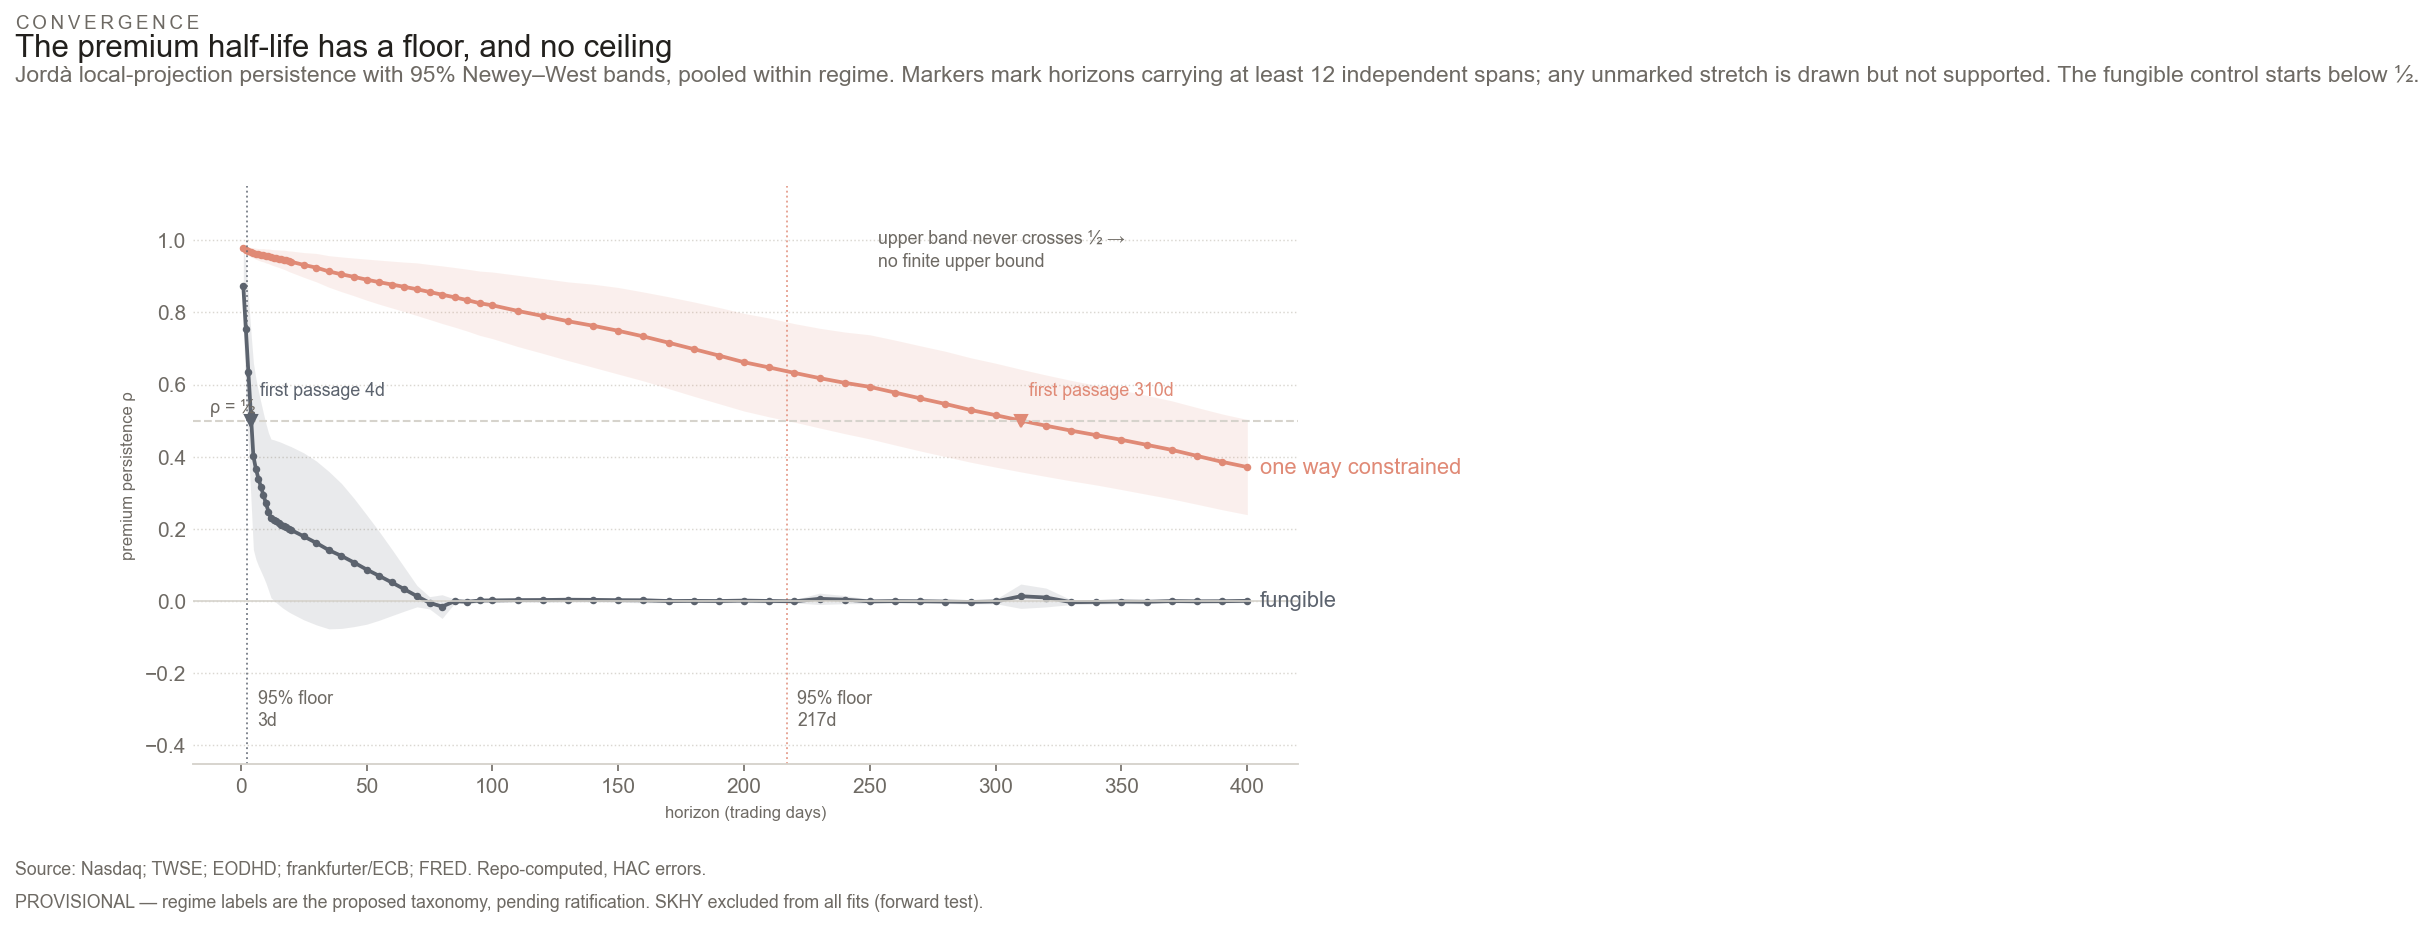

In [3]:
fig, ax = figures.g_convergence(run_panel())
fig;

**In plain terms**

- Gaps like this one close slowly. Ones where the trade works both ways close within days.
- Best case, on the evidence, is about ten and a half months. There is no worst case we can rule
  out — the data cannot say the gap ever halves.
- Anything you pay per day, you should assume you pay for at least ten months.

## Ablations — both feature families are cut

**M5** is each pair's own local-leg context (20-day realized vol, 60-day drawdown). **M6** is
each pair's own FX 20-day trend. In and out under identical folds — asserted, not assumed: the
first version of the M6 ablation dropped rows when the feature was added, so the two arms
scored different samples and RMSE appeared to improve while R² fell. That is only possible
when the sample moves underneath you.

*M5 is specified as "000660 deep history" and cannot be: 000660 is SKHY's local leg and SKHY
is never fitted. It is built per-pair on each pair's own local leg instead — the only form in
which the feature is both testable and inside the quarantine.*

In [4]:
def ablate(fams, label):
    b = s4_metrics_table(families=fams, use_features=False)
    x = s4_metrics_table(families=fams, use_features=True)
    j = b.merge(x, on=["regime", "horizon"], suffixes=("_b", "_x"))
    assert (j.n_b == j.n_x).all(), f"{label}: arms scored different samples"
    j["d_rmse"] = j.rmse_x - j.rmse_b
    j["d_r2"] = j.r2_x - j.r2_b
    j.insert(0, "family", label)
    return j[["family", "regime", "horizon", "n_b", "d_rmse", "d_r2"]]

abl = pd.concat([ablate(("m5",), "M5"), ablate(("m6",), "M6"),
                 ablate(("m5", "m6"), "M5+M6")], ignore_index=True)
print("identical folds CONFIRMED in every arm\n")
abl.round(5)

identical folds CONFIRMED in every arm



,family,regime,horizon,n_b,d_rmse,d_r2
0,M5,fungible,1,23207,0.00002,-0.00052
1,M5,fungible,5,23189,0.00038,-0.02310
2,M5,fungible,20,23114,0.00285,-0.18070
3,M5,fungible,60,22913,0.00629,-0.41038
4,M5,one_way_constrained,1,15490,0.00008,-0.00044
5,M5,one_way_constrained,5,15476,0.00032,-0.00212
6,M5,one_way_constrained,20,15426,0.00108,-0.00882
7,M5,one_way_constrained,60,15292,-0.00050,0.00552
8,M5,POOLED (all classes),1,38697,0.00005,-0.00041
9,M5,POOLED (all classes),5,38665,0.00036,-0.00464


**Verdict: cut.** RMSE worsens and R² falls at every horizon in every class. Hit rate moves up
marginally, not enough to offset either. A near-zero-to-negative delta cuts the family, and
**that is a finding, not a failure** — it says the premium's dynamics are its own rather than
an FX overlay, consistent with FX explaining ~1.2% of daily premium variance.

**Verdict: cut both.** M5 is the worse of the two — it costs the control 0.41 of R² at h=60.
Together they are no better than either alone, so no interaction is being missed.

### The degenerate-regime case, which M5 actually produced

At h=60 M5 **helps the minority class and hurts the dominant one**: constrained (n≈13,210)
gains Δr² +0.0039 while fungible (n≈23,207) loses 0.41, and the pooled row nets **−0.053**.

Reading only the improved cell — *"M5 helps the constrained regime at the horizon we care
about"* — would justify keeping a family that makes the panel measurably worse. That is why the
pooled row exists, why it is labelled, and why the detector that finds this pattern is computed
in `scripts/s4_table.py` rather than left to a reader comparing columns.

## Variance shares — and why they do not separate the classes

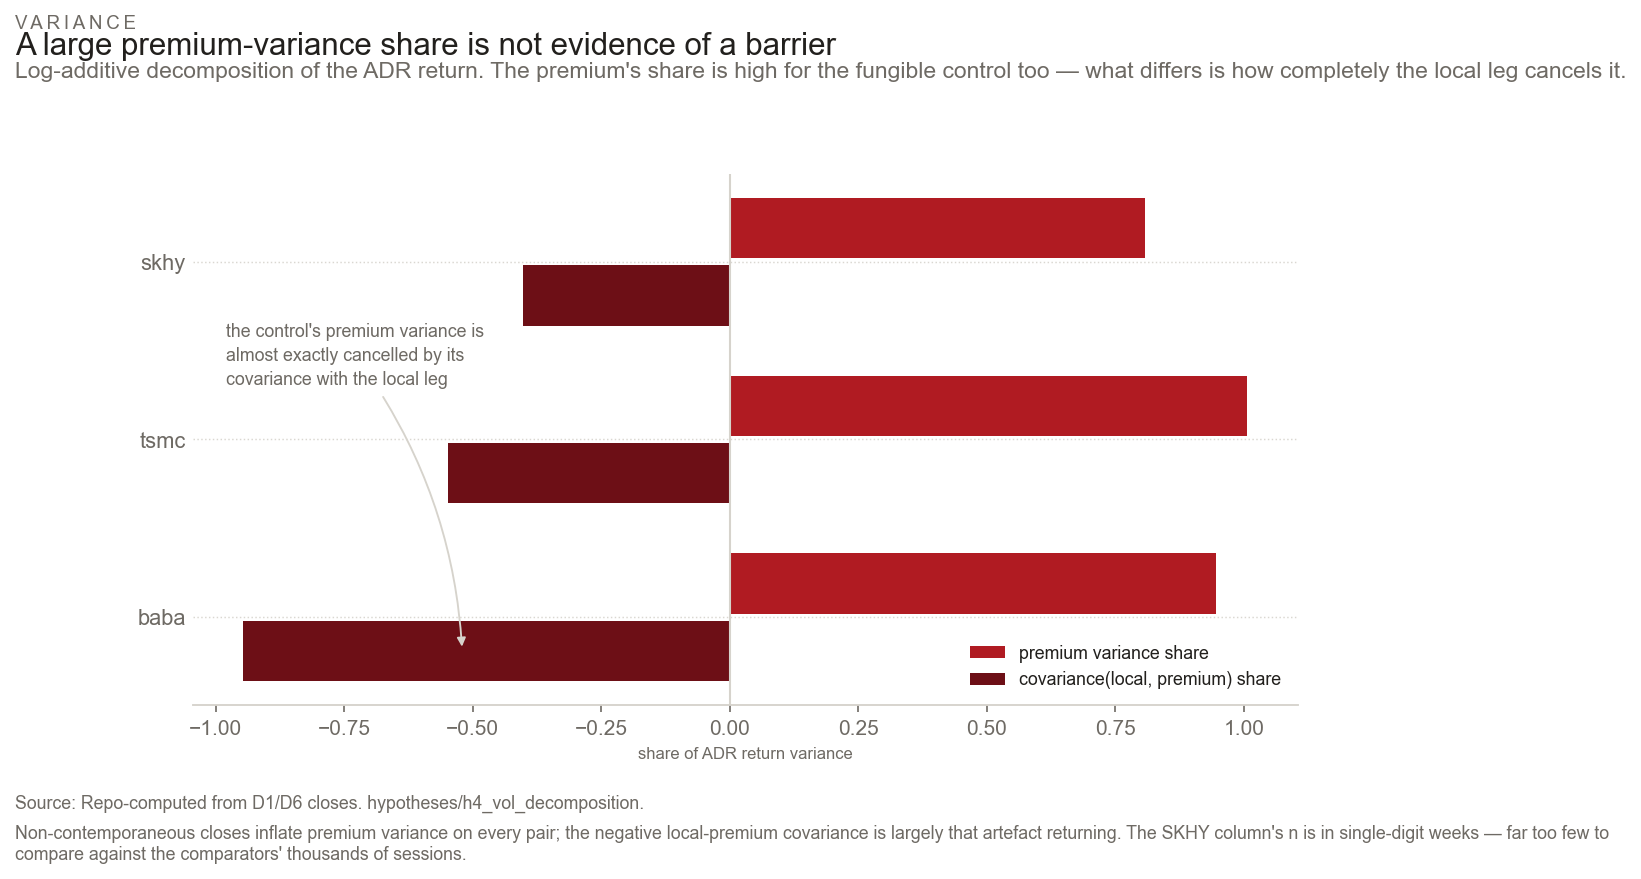

In [5]:
from hypotheses.h4_vol_decomposition.realized import compare_pairs
fig, ax = figures.g12_variance_shares(compare_pairs().to_dict("records"))
fig;

**In plain terms**

- Break the US share's daily moves into three parts: the Korean share, the currency, and the gap
  between them.
- The gap looks like most of the risk in every case — including the ones where the trade works
  both ways. So a big gap-share on its own proves nothing.
- The tell is that for a freely tradeable pair the gap almost exactly cancels against the local
  share: it opens and closes inside a day, mostly because the two markets close at different
  times.

**No regime-timeline figure, deliberately.** The session spec paired the variance figure with
one. There is nothing to plot: regime is a per-pair label read off a filing, so a timeline of
it is a horizontal line. The time-varying quantity is *binding-ness* — headroom — which the H5
monitor already reports as text, and which has a single observation on the capped programme.

## What this unlocks, and what it does not

The table's half-lives are what the trade sheets accrue financing against, and they are quoted
as a **floor with an open tail**: at least 220 trading days at 95%, no finite upper bound,
because ρ's upper confidence edge never crosses one half at any estimable horizon.

It does not unlock a point cost. Cost is linear in holding horizon and the horizon's upper
tail is open, so a point estimate would understate in the direction that flatters the trade.

Regenerate everything here with `just s4`. Research programme:
**[00 pitch](00_executive_pitch.ipynb)** · **[01 client note](01_client_note.ipynb)** ·
**[02 anatomy](02_premium_anatomy.ipynb)** · **[05 engines](05_hypothesis_engines.ipynb)**.